### 0. Imports

In [4]:
import pandas as pd
import numpy as np

import cv2
import rembg as rb
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import os
from pathlib import Path
import glob

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

### 1. Exploration

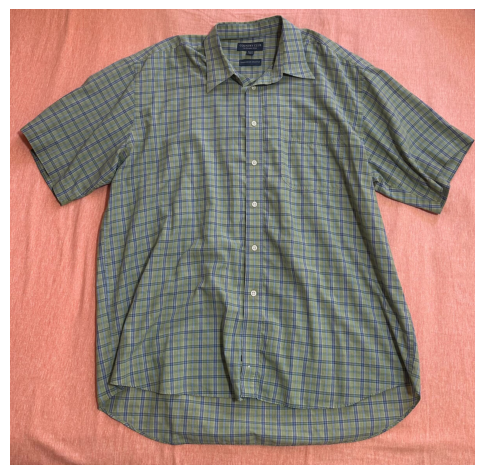

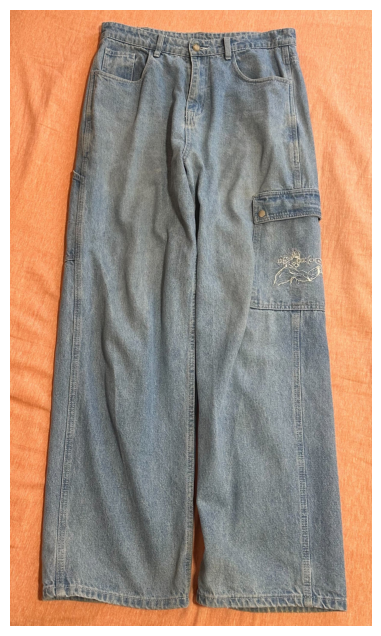

In [2]:
shirt_img_path = "../data/raw_images/shirt_1.jpg" 
shirt_img = cv2.imread(shirt_img_path)

shirt_img_rgb = cv2.cvtColor(shirt_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 8))
plt.imshow(shirt_img_rgb)
plt.axis('off') 
plt.show()

pants_img_path = "../data/raw_images/pants_1.jpg" 
pants_img = cv2.imread(pants_img_path)

pants_img_rgb = cv2.cvtColor(pants_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 8))
plt.imshow(pants_img_rgb)
plt.axis('off') 
plt.show()

### 2. Preprocess

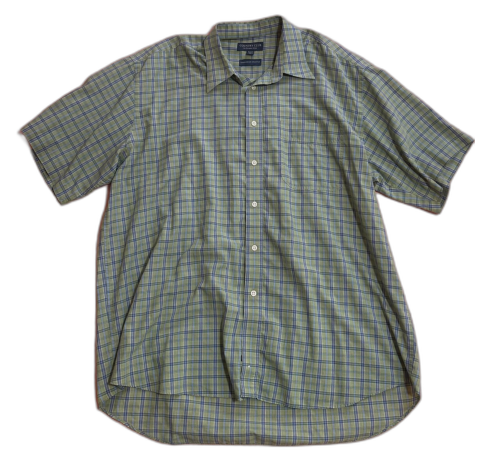

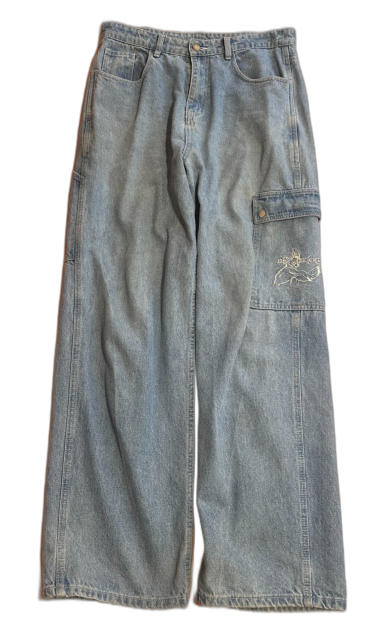

In [6]:
shirt_pil = Image.fromarray(shirt_img_rgb)
shirt_no_bg = rb.remove(shirt_pil)

pants_pil = Image.fromarray(pants_img_rgb)
pants_no_bg = rb.remove(pants_pil)

# Display background removed images
plt.figure(figsize=(6, 8))
plt.imshow(shirt_no_bg)
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 8))
plt.imshow(pants_no_bg)
plt.axis('off')
plt.show()

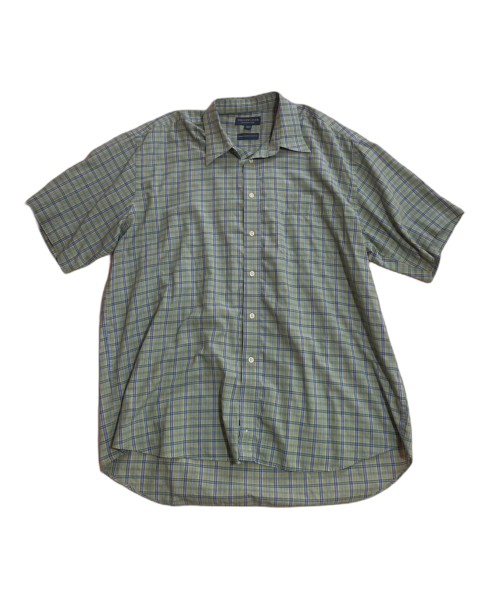

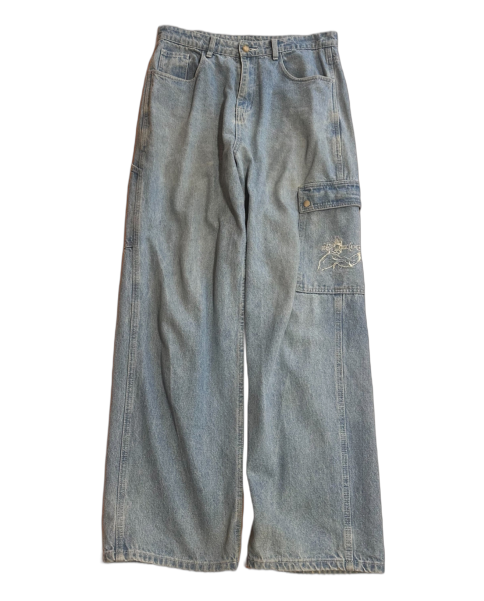

In [10]:
def crop_transparent_space(img):
    """Remove excess transparent space around the clothing item"""
    # getbbox() returns the bounding box of non-transparent pixels
    bbox = img.getbbox()
    
    if bbox:
        # Crop to the bounding box
        cropped = img.crop(bbox)
        return cropped
    else:
        # If no non-transparent pixels found, return original
        return img

def center_and_resize(img, target_size=(800, 1000), padding=50):
    """Crop transparent space, then resize with aspect ratio and center"""
    # Step 1: Remove excess transparent space
    cropped = crop_transparent_space(img)
    
    # Step 2: Add some padding back
    width, height = cropped.size
    padded_img = Image.new('RGBA', (width + padding*2, height + padding*2), (0, 0, 0, 0))
    padded_img.paste(cropped, (padding, padding), cropped)
    
    # Step 3: Resize with aspect ratio preserved
    original_width, original_height = padded_img.size
    target_width, target_height = target_size
    
    scale = min(target_width / original_width, target_height / original_height)
    new_width = int(original_width * scale)
    new_height = int(original_height * scale)
    
    img_resized = padded_img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Step 4: Center in final canvas
    final_img = Image.new('RGBA', target_size, (0, 0, 0, 0))
    x_offset = (target_width - new_width) // 2
    y_offset = (target_height - new_height) // 2
    final_img.paste(img_resized, (x_offset, y_offset), img_resized)
    
    return final_img

# Apply the full preprocessing
shirt_processed = center_and_resize(shirt_no_bg)
pants_processed = center_and_resize(pants_no_bg)

# Display final processed images
plt.figure(figsize=(6, 8))
plt.imshow(shirt_processed)
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 8))
plt.imshow(pants_processed)
plt.axis('off')
plt.show()